# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
from openpyxl import load_workbook
from functools import reduce
import re
import unicodedata
import json

# Read Data File

In [ ]:
file = "FatigueData-AM2022.xlsx"
xls = pd.ExcelFile(file)

print(xls.sheet_names)

['S-N', 'e-N', 'dadn', 'parameter']


In [ ]:
all_sheets = pd.read_excel(file, sheet_name=None)

for i, (sheet_name, df) in enumerate(all_sheets.items(), start=1):
    
    # # make row 2 the headers in "parameters" sheet
    # if sheet_name == "parameter":
    #     df = pd.read_excel(file,
    #                        sheet_name="parameter",
    #                        header=1)
    
    print(f"\nDataset {i}")
    print("Sheet:", sheet_name)
    print(df.columns.tolist())


Dataset 1
Sheet: S-N
['dataset id', 'life\nN (cycle)', 'stress amplitude\nσa (MPa)', 'runout']

Dataset 2
Sheet: e-N
['dataset id', 'life\nN (cycle)', 'strain amplitude\nεa (mm/mm)', 'runout']

Dataset 3
Sheet: dadn
['dataset id', 'stress intensity factor range\nΔK (MPa*m^(1/2))', 'crack growth rate \nda/dn (m/cycle)']

Dataset 4
Sheet: parameter
['Unnamed: 0', 'metadata', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'fatigue', 'Unnamed: 10', 'materials', 'AM', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'processing', 'testing', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'static mechanical properties', 'Unnamed: 43', 'Un

# Clean Data

## Remove Merged Headers
remove merged headers in row 1 of "parameters" and make row 2 the header row

In [ ]:
# modify workbook so row 2 is the header row for "parameter" sheet

# load workbook
wb = load_workbook(file)
ws = wb["parameter"]

#for ws in wb.worksheets:
ws.delete_rows(0)   # delete first row

wb.save("data_fatigue_headersfixed.xlsx")

file2 = "data_fatigue_headersfixed.xlsx"
xls = pd.ExcelFile(file2)

all_sheets = pd.read_excel(file2, sheet_name=None)

In [ ]:
for i, (sheet_name, df) in enumerate(all_sheets.items(), start=1):

    print("\n" + "="*60)
    print(f"Sheet {i}: {sheet_name}")
    print("="*60)

    print(df.describe())

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    # print("\nFirst rows:")
    # print(df.head())

    print("\nMissing values:")
    print(df.isnull().sum())


Sheet 1: S-N
         dataset id  life\nN (cycle)  stress amplitude\nσa (MPa)       runout
count  15146.000000     1.514600e+04                15146.000000  15146.00000
mean     792.986003     1.844821e+07                  285.818193      0.12221
std      457.581397     1.472127e+08                  189.421194      0.32754
min        1.000000     9.710731e+00                    5.760575      0.00000
25%      396.000000     6.502688e+04                  138.464799      0.00000
50%      780.000000     2.443496e+05                  249.958188      0.00000
75%     1187.000000     1.599869e+06                  375.990143      0.00000
max     1610.000000     8.496147e+09                 1591.682267      1.00000

Shape:
(15146, 4)

Columns:
['dataset id', 'life\nN (cycle)', 'stress amplitude\nσa (MPa)', 'runout']

Missing values:
dataset id                    0
life\nN (cycle)               0
stress amplitude\nσa (MPa)    0
runout                        0
dtype: int64

Sheet 2: e-N
        d

The "parameters" sheet includes many missing values. The others include none. 

## Merged Sheets
merge all the sheets where possible on dataset id

In [ ]:
dfs = list(all_sheets.values())

merged_df = reduce(lambda left, right: pd.merge(left,
                                                right,
                                                on="dataset id",
                                                how="outer"
                                                ),
                    dfs
                 )

KeyError: 'dataset id'

In [ ]:
print(merged_df.shape)
print(merged_df.columns.to_list())
print(merged_df.head())

## Remove Columns
remove irrelevant or duplicate columns

In [ ]:
merged_df.drop([])

## Missing Values
missing values in relevant columns in "parameters" sheet are handled

In [ ]:
for i, (sheet_name, df) in enumerate(all_sheets.items(), start=1):
    if sheet_name == "parameter":
        print("\nColumns:")
        print(df.columns.tolist())
        
        print("\nMissing values:")
        print(df.isnull().sum())


Columns:
['dataset id', 'title', 'authors', 'source of the publication', 'year of publication', 'institution', 'country and region', 'funding agency', 'DOI', 'types of fatigue data', 'method of extraction', 'name of the material', 'types of AM', 'AM machine', 'power \n(W)', 'scan speed \n(mm/s)', 'hatch space \n(μm)', 'layer thickness \n(μm)', 'preheat temperature \n(°C)', 'direciton of specimen \n(°)', 'AM environment', 'scan pattern', 'layer scan rotation \n(°)', 'voltage \n(V)', 'current \n(A)', 'speed function', 'powder feed rate \n(g/s)', 'wire feed rate \n(mm/s)', 'types of feedstock', 'size of feedstock \n(μm)', 'processing sequence and parameters', 'types of fatigue tests', 'fatigue temperature \n(°C)', 'fatigue environment', 'load ratio', 'frequency \n(Hz)', 'fatigue machine', 'fatigue standard', 'load control', 'specimens description', 'critical cross-section size of specimens\n(mm)', 'stress concentration factor of specimens', "Young's modulus \n(GPa)", 'yield strength \n(M

## Standarize Column Names

In [ ]:
# standardize column names across datasets
for sheet_name, df in all_sheets.items():
    
    rename_map = {
        "stress(mpa)": "stress_max",
        "stress_mpa": "stress_max",
        "stressmpa": "stress_max",
        "s_mpa": "stress_max",
        "sa_mpa": "stress_amp",
        "cycles": "Nf",
        "fatigue_life": "Nf",
        "n": "Nf",
        "nf": "Nf",
        "î”k_(mpaâˆšm)": "deltaK",
        "ik_mpaasm": "deltaK",
        "dmax": "sqrt_A",
        "r": "r-ratio",
        "rratio": "r-ratio",
        "t": "temperature_k",
        "kt": "Kt"
    }

    symbol_map = {
        "σ": "s",
        "Δ": "delta",
        "µ": "micro",
        "√": "sqrt",
    }
    
    # df = df.rename(columns=rename_map)

    # print(df.columns.to_list())

In [ ]:
# cleanup column names across datasets
cleaned_sheets = {}

for sheet_name, df in all_sheets.items():
    
    cleaned_cols = []
    
    for col in df.columns:

        col = str(col)

        # replace Greek letters for readability
        for symbol, replacement in symbol_map.items():
            col = col.replace(symbol, replacement)

        # clean column names
        col = unicodedata.normalize("NFKD", col)
        col = col.encode("ascii", "ignore").decode()
        col = col.strip().lower().replace(" ", "_").replace("/", "_").strip("_")
        col = re.sub(r"[^a-z0-9_]", "", col)
        col = re.sub(r"_+", "_", col)

        cleaned_cols.append(col)

    df.columns = cleaned_cols

    # rename columns to standardize across datasets
    df = df.rename(columns=rename_map)

    cleaned_sheets[sheet_name] = df

    # print column names after cleaning and renaming
    print(df.columns.tolist())

['dataset_id', 'lifen_cycle', 'stress_amplitudesa_mpa', 'runout']
['dataset_id', 'lifen_cycle', 'strain_amplitudea_mm_mm', 'runout']
['dataset_id', 'stress_intensity_factor_rangedeltak_mpam1_2', 'crack_growth_rate_da_dn_m_cycle']
['dataset_id', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direciton_of_specimen_', 'am_environment', 'scan_pattern', 'layer_scan_rotation_', 'voltage_v', 'current_a', 'speed_function', 'powder_feed_rate_g_s', 'wire_feed_rate_mm_s', 'types_of_feedstock', 'size_of_feedstock_m', 'processing_sequence_and_parameters', 'types_of_fatigue_tests', 'fatigue_temperature_c', 'fatigue_environment', 'load_ratio', 'frequency_hz', 'fatigue_machine', 'fatigue_standard', 'load_control', 'specimen

# Build Dataset Dictionary

In [ ]:
# create a dictionary to store the datasets and their metadata
datasets = {}

category_map = {
    1: "fatigue_life",
    2: "fracture_mechanics",
    3: "fatigue_life",
    4: "stress_concentration",
    5: "stress_concentration",
    6: "stress_concentration",
    7: "stress_concentration",
    8: "fatigue_life",
    9: "stress_concentration",
    10: "stress_concentration",
    11: "defect_informed",
    12: "defect_informed",
}

material_map = {
    1: "LZ50 steel",
    2: "SLM 316L",
    3: "Al7075-T6",
    4: "Al2024",
    5: "Al7175",
    6: "Ti-4.5Al-3V-2Fe-2Mo",
    7: "ZK60A-T5",
    8: "AMS 5707",
    9: "Inconel 718",
    10: "Al7075-T6",
    11: "Al-Mg4.5-Mn",
    12: "Ti-6.5Al-2Zr-Mo-V",
}

for i, (sheet_name, df) in enumerate(cleaned_sheets.items(), start=1):

    datasets[sheet_name] = {
        "data": df,
        "case": i,
        "material": material_map.get(i),
        "category": category_map.get(i),
        "n_samples": len(df),
        "columns": list(df.columns),
        "target": "Nf" if "Nf" in df.columns else None,
        "input_features": [col for col in df.columns if col != "Nf"],
        "physics_features": [
            col for col in df.columns 
            if col in ["deltaK", "sqrt_A", "Kt", "r-ratio", "defect_size_m"]
        ],
        "notes": ""
    }

In [ ]:
# print summary of datasets
for name, info in datasets.items():
    print("\n" + "="*60)
    print(name)
    print("Case:", info["case"])
    print("Material:", info["material"])
    print("Category:", info["category"])
    print("Samples:", info["n_samples"])
    print("Inputs:", info["input_features"])
    print("Physics:", info["physics_features"])


S-N
Case: 1
Material: LZ50 steel
Category: fatigue_life
Samples: 15146
Inputs: ['dataset_id', 'lifen_cycle', 'stress_amplitudesa_mpa', 'runout']
Physics: []

e-N
Case: 2
Material: SLM 316L
Category: fracture_mechanics
Samples: 1840
Inputs: ['dataset_id', 'lifen_cycle', 'strain_amplitudea_mm_mm', 'runout']
Physics: []

dadn
Case: 3
Material: Al7075-T6
Category: fatigue_life
Samples: 178061
Inputs: ['dataset_id', 'stress_intensity_factor_rangedeltak_mpam1_2', 'crack_growth_rate_da_dn_m_cycle']
Physics: []

parameter
Case: 4
Material: Al2024
Category: stress_concentration
Samples: 2460
Inputs: ['dataset_id', 'title', 'authors', 'source_of_the_publication', 'year_of_publication', 'institution', 'country_and_region', 'funding_agency', 'doi', 'types_of_fatigue_data', 'method_of_extraction', 'name_of_the_material', 'types_of_am', 'am_machine', 'power_w', 'scan_speed_mm_s', 'hatch_space_m', 'layer_thickness_m', 'preheat_temperature_c', 'direciton_of_specimen_', 'am_environment', 'scan_pattern

In [ ]:
# # add each sheet to dictionary

# # fatigue life datasets
# # sheets 1, 3, 8

# # Sheet 1: Case 1 LZ50 steel
# datasets["SLZ50 steel"] = {
#     "data": df,
#     "category": "fatigue_life",
#     "material": "SLZ50 steel",
#     "target": "Nf",
#     "input_features": [
#         "temperature_k",
#         "",
#         "sqrt_A"
#     ],
#     "physics_features": [
#         "Nf"
#     ],
#     "notes": "Contains XCT-derived defect sizes"
# }

# # Sheet 2: Case 2 SLM 316l
# datasets["SLM_316L"] = {
#     "data": df,
#     "category": "fatigue_life",
#     "material": "SLM 316L",
#     "target": "Nf",
#     "input_features": [
#         "stress_amp",
#         "r-ratio",
#         "sqrt_A"
#     ],
#     "physics_features": [
#         "deltaK"
#     ],
#     "notes": "Contains XCT-derived defect sizes"
# }

In [ ]:
# # add metadata for each dataset
# datasets["Case 1 LZ50 steel"]["material"] = "LZ50 steel"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 2 SLM 316l"]["material"] = "SLM 316L"
# datasets["Case 1 LZ50 steel"]["category"] = ""

# datasets["Case 3 7075_T6_ratio"]["material"] = "7075_T6_ratio"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 4 Al2024_T4"]["material"] = "Al2024_T4"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 4 Al7175_T7511"]["material"] = "Al7175_T7511"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 4 Ti-4.5Al-3V-2Fe-2Mo"]["material"] = "Ti-4.5Al-3V-2Fe-2Mo"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case4 ZK60A-T5"]["material"] = "ZK60A-T5"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# datasets["Case 5 AMS 5707"]["material"] = "AMS 5707"
# datasets["Case 1 LZ50 steel"]["category"] = "raw fatigue"

# Explore Each Sheet

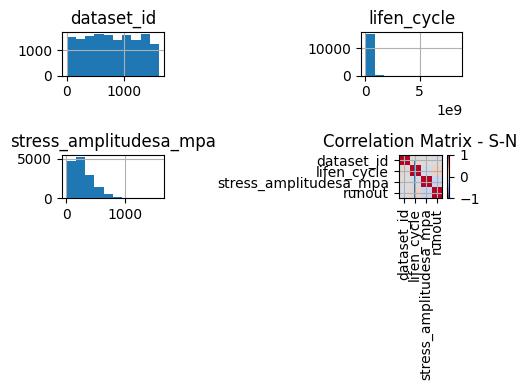

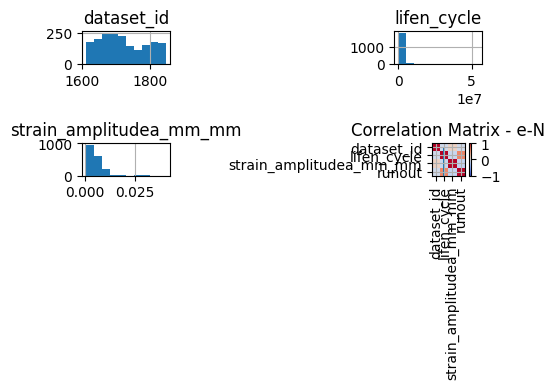

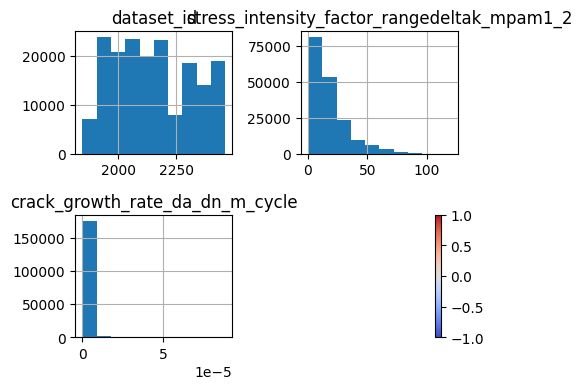

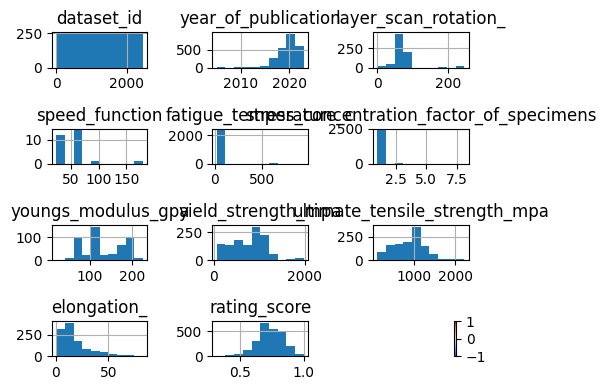

In [ ]:
for i, (sheet_name, df) in enumerate(cleaned_sheets.items(), start=1):

    #numerical summary
    df.describe()

    # histograms of numerical columns
    df.hist(figsize=(5,4))

    # correlation matrix
    corr = df.corr(numeric_only=True)

    plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr)), corr.columns, rotation=90)
    plt.yticks(range(len(corr)), corr.columns)
    plt.title(f"Correlation Matrix - {sheet_name}")
    plt.tight_layout()
    plt.show()

# Export Clean Sheet

In [ ]:
# export cleaned sheets to one Excel workbook
with pd.ExcelWriter("data_zhou_cleaned.xlsx") as writer:
    for sheet_name, df in cleaned_sheets.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

In [ ]:
# metadata only, without the actual dataframe objects
metadata = {}

for sheet_name, info in datasets.items():
    metadata[sheet_name] = {
        key: value
        for key, value in info.items()
        if key != "data"
    }

with open("data_zhou_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)